# VD Geometry — TPC volume Viewer
Displays the TPC volumes from the DUNE geometry JSON using matplotlib voxels.

In [1]:
%load_ext autoreload
%autoreload 2

# %matplotlib widget


In [2]:
import dunetrg.data.geometry

In [3]:
import matplotlib.pyplot as plt
import os
from pathlib import Path
from dunetrg.analysis.viz.geo_dg import plot_geometry_3d, plot_geometry_3d, animate_tpc_volumes, compare_cryostats_3d
from dunetrg.data.geometry.detgeometry import load_geodata
import json
from importlib.resources import files


In [4]:
geodata_1x8x14 = load_geodata('dunevd10kt_1x8x14_3view_30deg_geo.json')
geodata_1x8x6 = load_geodata('dunevd10kt_1x8x6_3view_30deg_geo.json')
geodata_vd10kt = load_geodata('dunevd10kt_geo.json')


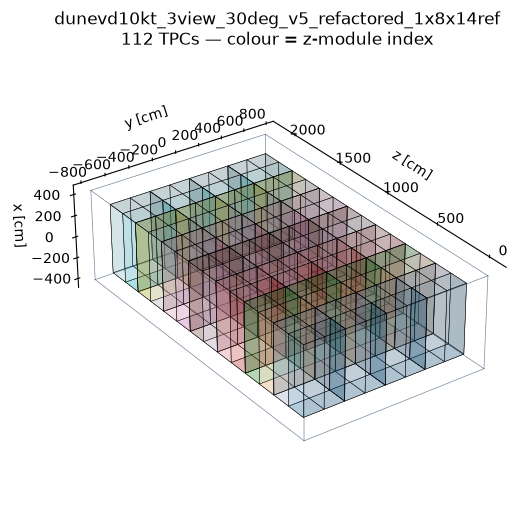

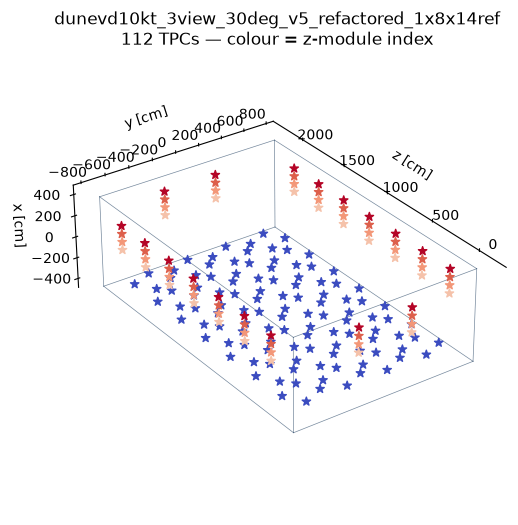

In [5]:
# GEO_FILE = Path('../../../../data/vd/geo/dunevd10kt_1x8x14_3view_30deg_geo.json')
# with open(GEO_FILE) as f:
    # geo = json.load(f)

figsize = (12,6)
show_beam=False
show_drift=False
show_cryostat_dimensions=False
annotations_overrides={'beam_anchor_y': 650, 'drift_anchor_z': 2100}

fig, ax = plot_geometry_3d(
    geodata_1x8x14, 
    show_cryostat_dimensions=show_cryostat_dimensions,
    # show_axes=False,
    # show_tpcs=False,
    show_opdets=False,
    show_beam=show_beam,
    show_drift=show_drift,
    show_grid=False,
    figsize=figsize,
    annotation_overrides=annotations_overrides
    )
fig, ax = plot_geometry_3d(
    geodata_1x8x14, 
    show_cryostat_dimensions=show_cryostat_dimensions,
    # show_axes=False,
    show_tpcs=False,
    # show_opdets=False,
    show_beam=show_beam,
    show_drift=show_drift,
    show_grid=False,
    figsize=figsize,
    annotation_overrides=annotations_overrides
    )
# plt.show()

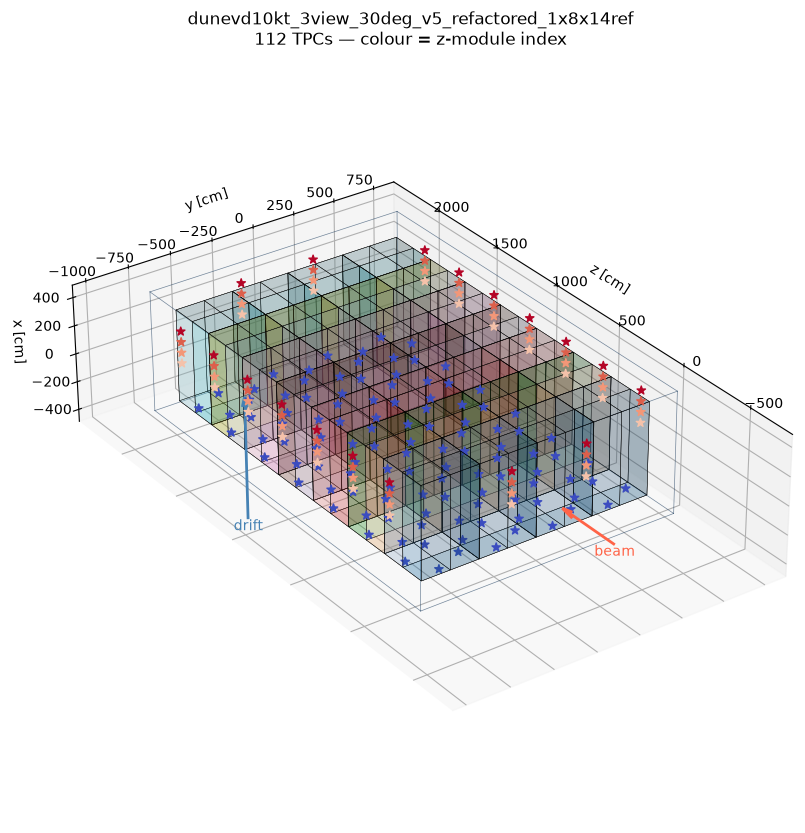

In [6]:
# GEO_FILE = Path('../../data/vd/geo/dunevd10kt_1x8x6_3view_30deg_geo.json')
fig, ax = plot_geometry_3d(
    geodata_1x8x14, 
    # show_cryostat_dimensions=True,
    # show_axes=False,
    show_beam=True,
    show_drift=True
    )
plt.show()

## VD 1x8x6

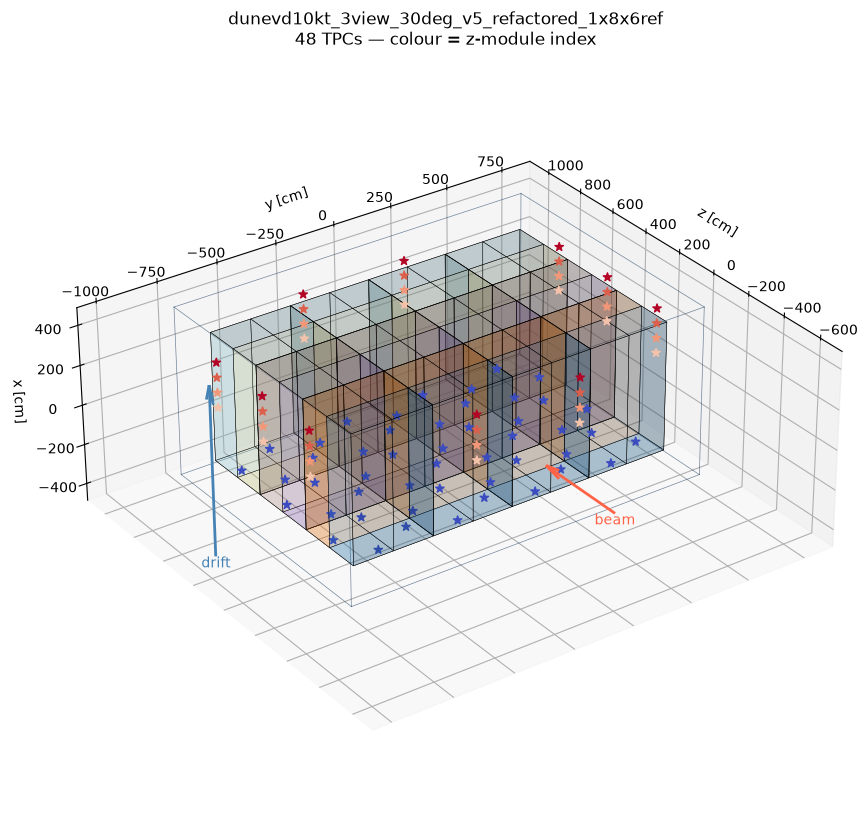

In [7]:

fig, ax = plot_geometry_3d(
    geodata_1x8x6, 
    # show_cryostat_dimensions=True,
    # show_axes=False,
    show_beam=True,
    show_drift=True
    )
plt.show()


## FDHD 

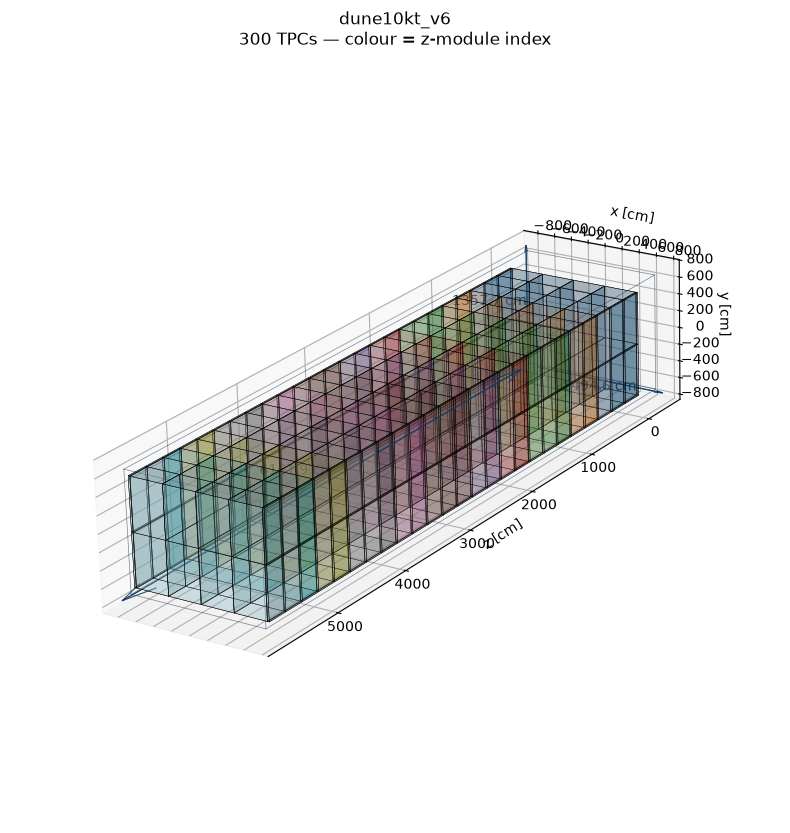

In [8]:
geodata_hd10kt = load_geodata('dune10kt_geo.json')

fig, ax = plot_geometry_3d(geodata_hd10kt, drift_type='hd', show_opdets=False, show_cryostat_dimensions=True)
plt.show()

## FDVD

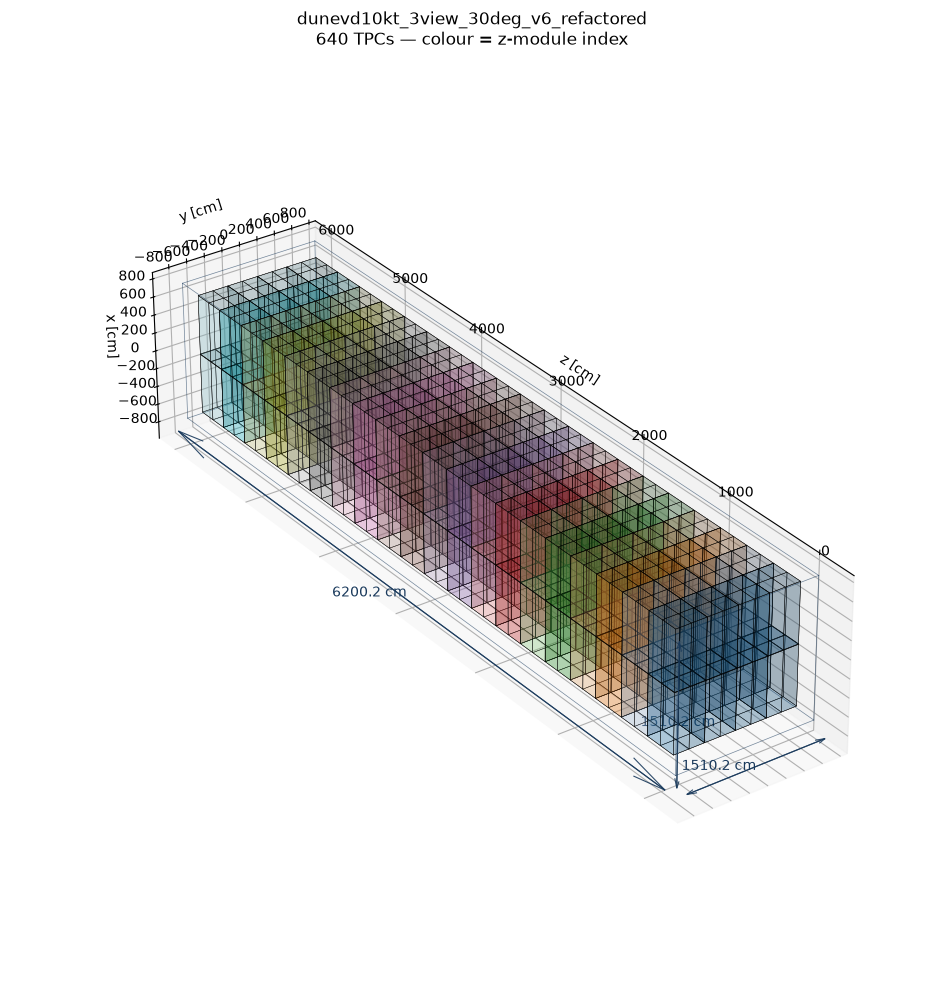

In [9]:

fig, ax = plot_geometry_3d(
    geodata_vd10kt,
    drift_type='vd',
    show_opdets=False,
    show_cryostat_dimensions=True,
    figsize=(16,12),
)
plt.show()

## HD 1x2x6

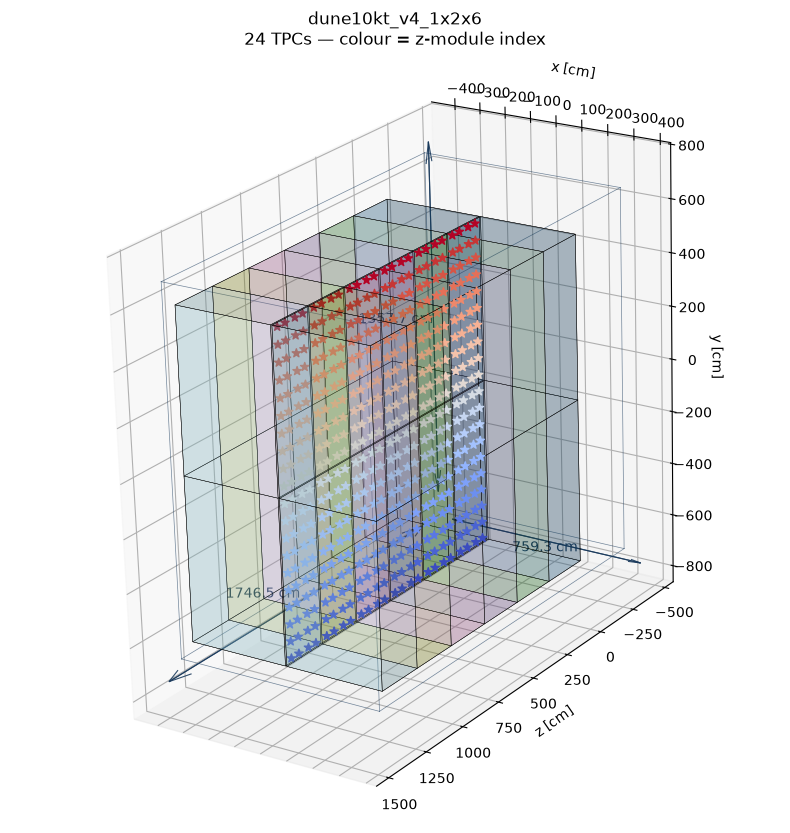

In [10]:

geodata_1x2x6 = load_geodata('dune10kt_1x2x6_geo.json')

fig, ax = plot_geometry_3d(geodata_1x2x6, drift_type='hd', show_cryostat_dimensions=True)
plt.show()

## VD Cryostats comparison

(<Figure size 1200x800 with 1 Axes>,
 <Axes3D: title={'center': 'Cryostat geometry comparison'}, xlabel='x [cm]', ylabel='y [cm]', zlabel='z [cm]'>)

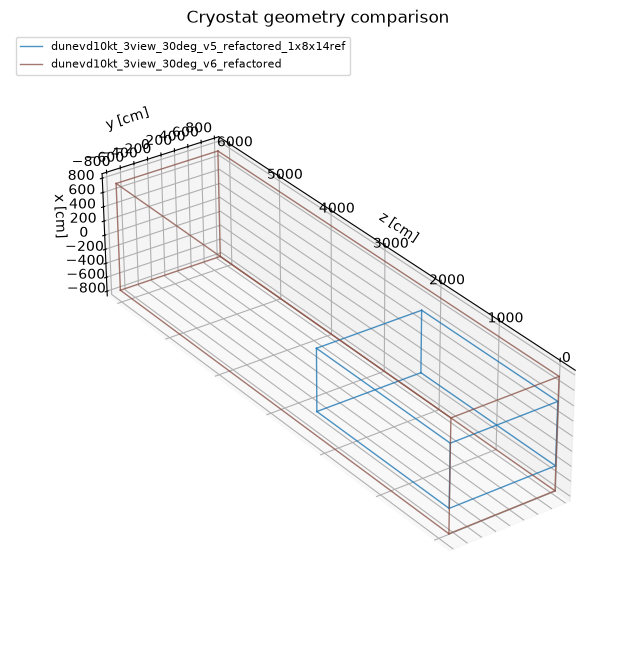

In [11]:
compare_cryostats_3d([geodata_1x8x14, geodata_vd10kt ],drift_type='vd')

## HD Cryostats comparison

(<Figure size 1200x800 with 1 Axes>,
 <Axes3D: title={'center': 'Cryostat geometry comparison'}, xlabel='x [cm]', ylabel='y [cm]', zlabel='z [cm]'>)

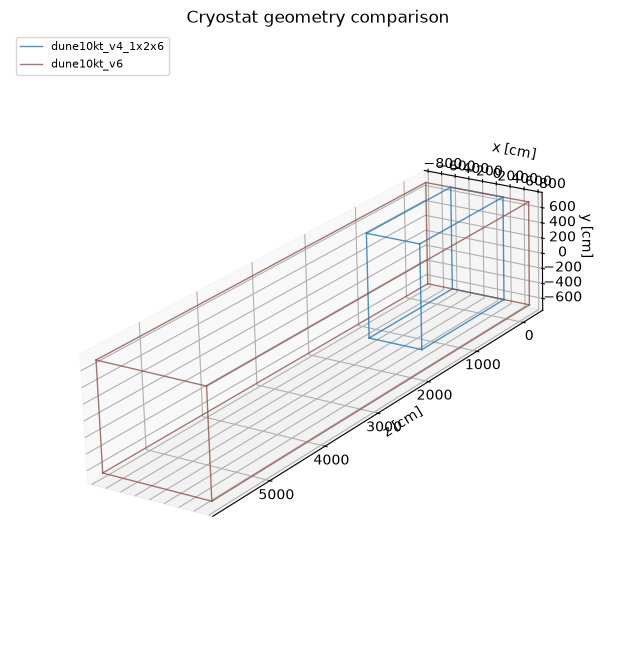

In [12]:
compare_cryostats_3d([geodata_1x2x6, geodata_hd10kt ],drift_type='hd')

In [13]:
# animate_tpc_volumes(GEO_FILE, 'tpc_x.gif', show_opdets=False, rotation_axis=(1, 0, 0), n_frames=150, fps=15, drift_type='hd')  # tumble around y
#animate_tpc_volumes(GEO_FILE, 'tpc_y.gif', show_opdets=True, rotation_axis=(0, 1, 0), n_frames=150, fps=15, drift_type='hd')  # tumble around y
# animate_tpc_volumes(GEO_FILE, 'tpc_z.gif', show_opdets=False, rotation_axis=(0, 0, 1), n_frames=150, fps=15, drift_type='hd')  # tumble around z


In [ ]:
# GEO_FILE = Path(os.environ['DTRG_DATA_ROOT']) / 'vd/geo/dunevd10kt_1x8x14_3view_30deg_geo.json'  # TODO(migration): path not found under DTRG_DATA_ROOT; nearest match is vd/1x8x6/geo/dunevd10kt_1x8x14_3view_30deg_geo.json
animate_tpc_volumes(geodata_1x8x14, 'tpc_x.gif', show_opdets=True, rotation_axis=(1, 0, 0), n_frames=300, fps=15, drift_type='vd')  # tumble around y


Rendering 300 frames…
Saved to tpc_x.gif


In [ ]:
from dunetrg.analysis.viz.geo_dg import plot_geometry_2d

In [ ]:
plot_geometry_2d(geodata_1x8x14)

In [ ]:
for i in [28, 29]:
    print(geodata_1x8x14.tpc_by_id(i).y_range.center)
    print(geodata_1x8x14.tpc_by_id(i).z_range.center)
